In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, FirstDifferenceOLS
from statsmodels.tsa.stattools import adfuller
from scipy.stats.mstats import winsorize
import scipy.stats as stats
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la
from linearmodels.panel import RandomEffects
warnings.filterwarnings('ignore')

df = pd.read_csv('final_panel.csv')

macro_raw = ['Average Key Rate', 'Average Inflation', 'Average GDP', 'Average USD/RUB Rate']
for col in macro_raw:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(' ', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df['year'] = df['Date'].str[:4].astype(int)
df['quarter'] = df['Date'].str[-1].astype(int)
df['Date'] = pd.PeriodIndex(df['Date'], freq='Q').to_timestamp()
df = df.sort_values(['bank_id', 'Date']).set_index(['bank_id', 'Date'])

df['profit_discrete'] = df.groupby(['bank_id', 'year'])['net_profit'].diff(1)
df['profit_discrete'] = df['profit_discrete'].fillna(df['net_profit'])
df['profit_win'] = winsorize(df['profit_discrete'], limits=[0.02, 0.02])

df['ln_assets'] = np.log(df['avg_active_sum'].replace(0, np.nan))

df['Real_Key_Rate'] = df['Average Key Rate'] - df['Average Inflation']
df['d_ln_GDP'] = np.log(df['Average GDP']).groupby(level='bank_id').diff(4) * 100
df['USD_Growth'] = df['Average USD/RUB Rate'].groupby(level='bank_id').pct_change(1) * 100


features = ['Real_Key_Rate', 'd_ln_GDP', 'USD_Growth', 'ln_assets', 'profit_win']
for col in features:
    df[f'{col}_lag1'] = df.groupby(level='bank_id')[col].shift(1)

df_model = df.dropna(subset=[f'{f}_lag1' for f in features] + ['profit_win'])

print("ТЕСТЫ НА СТАЦИОНАРНОСТЬ: FISHER-ADF PANEL TEST")


def fisher_panel_unit_root_test(series_name, data):
    p_vals = []
    banks = data.index.levels[0]
    for bank in banks:
        series = data.xs(bank, level='bank_id')[series_name].dropna()
        if len(series) > 10:
            pval = adfuller(series)[1]
            pval = max(pval, 1e-10)
            p_vals.append(pval)

    N = len(p_vals)
    fisher_stat = -2 * np.sum(np.log(p_vals))
    p_value = stats.chi2.sf(fisher_stat, 2 * N)

    status = "Стационарен I(0)" if p_value < 0.05 else "Нестационарен I(1)"
    print(f"[{status}] {series_name:15s} | Fisher Stat: {fisher_stat:.2f} | p-value: {p_value:.4f}")

for var in ['profit_win', 'Real_Key_Rate', 'd_ln_GDP', 'USD_Growth']:
    fisher_panel_unit_root_test(var, df_model)



print("БАЗОВАЯ МОДЕЛЬ (FE + DRISCOLL-KRAAY SE)")

macro_exog = ['Real_Key_Rate', 'd_ln_GDP', 'USD_Growth']
lagged_exog = [f"{f}_lag1" for f in macro_exog]
base_exog = macro_exog + lagged_exog + ['ln_assets', 'profit_win_lag1']

X_base = sm.add_constant(df_model[base_exog])
Y = df_model['profit_win']


mod_base = PanelOLS(Y, X_base, entity_effects=True)
res_base = mod_base.fit(cov_type='kernel')
print(res_base.summary)

print("\n=== ТЕСТ ХАУСМАНА ===")

def hausman_test(fe_model, re_model):
    b_fe = fe_model.params[fe_model.params.index != 'const']
    b_re = re_model.params[re_model.params.index != 'const']
    v_fe = fe_model.cov.loc[b_fe.index, b_fe.index]
    v_re = re_model.cov.loc[b_re.index, b_re.index]
    b_diff = b_fe - b_re
    v_diff = v_fe - v_re
    df = len(b_fe)

    try:
        h_stat = b_diff.dot(la.inv(v_diff)).dot(b_diff)
        p_value = stats.chi2.sf(h_stat, df)
        return h_stat, p_value, df
    except la.LinAlgError:
        print("Ошибка: Матрица разности ковариаций не положительно определена (вырождена).")
        print("В малых панелях это часто означает, что FE и RE дают почти идентичные оценки.")
        return None, None, None

mod_fe_unadj = PanelOLS(Y, X_base, entity_effects=True)
res_fe_unadj = mod_fe_unadj.fit(cov_type='unadjusted')

mod_re = RandomEffects(Y, X_base)
res_re = mod_re.fit(cov_type='unadjusted')

# 3. Проводим тест
h_stat, p_val, degrees = hausman_test(res_fe_unadj, res_re)

if h_stat is not None:
    print(f"Статистика Хаусмана (Chi-squared): {h_stat:.4f}")
    print(f"Степени свободы (df): {degrees}")
    print(f"P-value: {p_val:.4f}")

    print("\n[ВЫВОД]")
    if p_val < 0.05:
        print("p-value < 0.05 -> Отвергаем H0.")
        print("Оценки RE несостоятельны (индивидуальные эффекты коррелируют с регрессорами).")
        print("Выбор: СТРОГО FIXED EFFECTS (FE).")
    else:
        print("p-value >= 0.05 -> Нет оснований отвергнуть H0.")
        print("Обе модели состоятельны, но RE эффективнее.")
        print("Выбор: RANDOM EFFECTS (RE).")

ТЕСТЫ НА СТАЦИОНАРНОСТЬ: FISHER-ADF PANEL TEST
[Нестационарен I(1)] profit_win      | Fisher Stat: 5.06 | p-value: 0.8873
[Нестационарен I(1)] Real_Key_Rate   | Fisher Stat: 10.93 | p-value: 0.3632
[Стационарен I(0)] d_ln_GDP        | Fisher Stat: 25.63 | p-value: 0.0043
[Стационарен I(0)] USD_Growth      | Fisher Stat: 230.26 | p-value: 0.0000
БАЗОВАЯ МОДЕЛЬ (FE + DRISCOLL-KRAAY SE)
                          PanelOLS Estimation Summary                           
Dep. Variable:             profit_win   R-squared:                        0.4069
Estimator:                   PanelOLS   R-squared (Between):              0.8376
No. Observations:                 180   R-squared (Within):               0.4069
Date:                Wed, May 13 2026   R-squared (Overall):              0.6837
Time:                        22:52:58   Log-likelihood                   -3451.0
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-stat

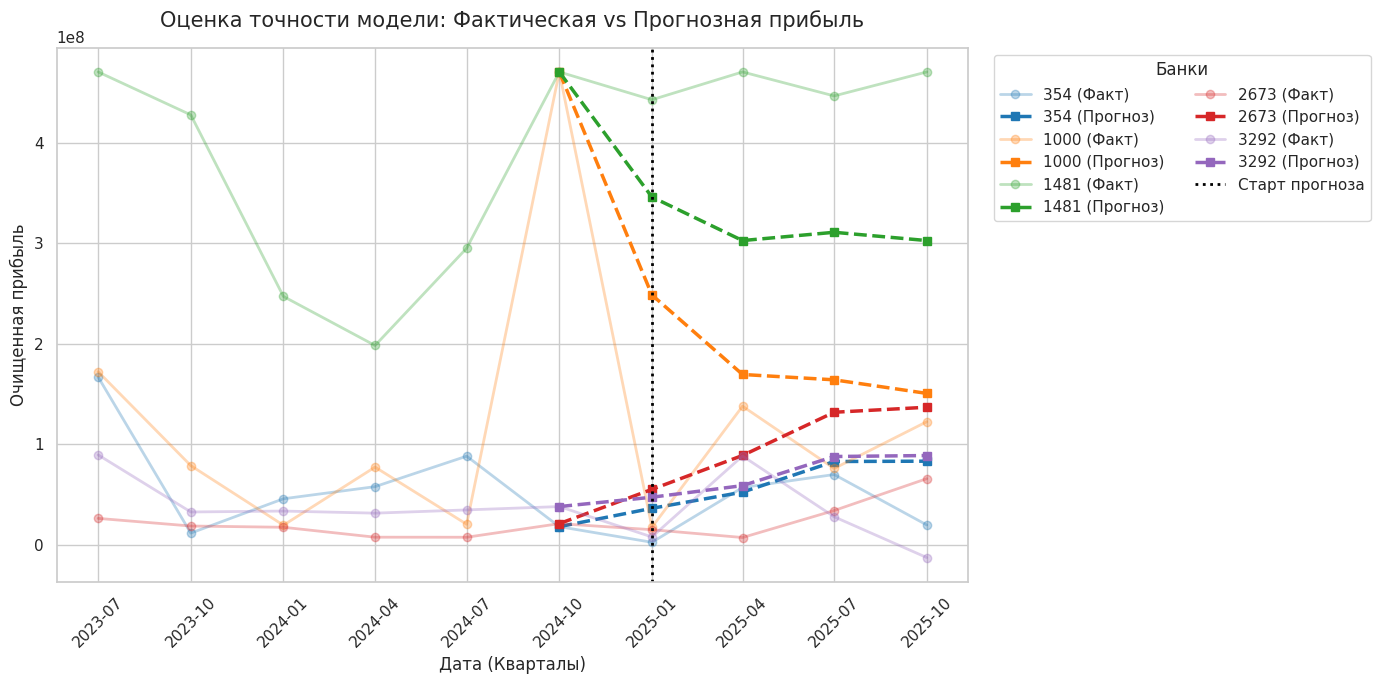

In [8]:
df_model = df.dropna(subset=[f'{f}_lag1' for f in features] + ['ln_assets', 'profit_win', 'd_ln_GDP'])

cutoff_date = pd.to_datetime('2024-12-31')

df_train = df_model[df_model.index.get_level_values('Date') <= cutoff_date]

df_forecast_data = df_model[df_model.index.get_level_values('Date') > cutoff_date]

macro_exog = ['Real_Key_Rate', 'd_ln_GDP', 'USD_Growth']
lagged_exog = [f"{f}_lag1" for f in macro_exog]
base_exog = macro_exog + lagged_exog + ['ln_assets', 'profit_win_lag1']

X_train = sm.add_constant(df_train[base_exog])
Y_train = df_train['profit_win']

mod_base = PanelOLS(Y_train, X_train, entity_effects=True)
res_base = mod_base.fit(cov_type='kernel')

betas = res_base.params
const = betas.get('const', 0)
fixed_effects = res_base.estimated_effects.groupby(level='bank_id').mean()['estimated_effects'].to_dict()

forecast_results = []
unique_banks = df_model.index.get_level_values('bank_id').unique()
forecast_dates = sorted(df_forecast_data.index.get_level_values('Date').unique())

for bank in unique_banks:
    bank_train = df_train.xs(bank, level='bank_id')
    bank_test = df_forecast_data.xs(bank, level='bank_id')
    bank_fe = fixed_effects.get(bank, 0)


    current_profit_lag1 = bank_train['profit_win'].iloc[-1]


    for current_date in forecast_dates:
        if current_date not in bank_test.index:
            continue

        row = bank_test.loc[current_date]


        X_t = {
            'Real_Key_Rate': row['Real_Key_Rate'],
            'd_ln_GDP': row['d_ln_GDP'],
            'USD_Growth': row['USD_Growth'],
            'Real_Key_Rate_lag1': row['Real_Key_Rate_lag1'],
            'd_ln_GDP_lag1': row['d_ln_GDP_lag1'],
            'USD_Growth_lag1': row['USD_Growth_lag1'],
            'ln_assets': row['ln_assets'],
            'profit_win_lag1': current_profit_lag1
        }

        pred_profit = const + bank_fe + sum(X_t[k] * betas[k] for k in X_t.keys())

        forecast_results.append({
            'bank_id': bank,
            'Date': current_date,
            'Predicted_Profit': pred_profit
        })

        current_profit_lag1 = pred_profit

df_forecast = pd.DataFrame(forecast_results)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))
colors = sns.color_palette("tab10", len(unique_banks))

for i, bank in enumerate(unique_banks):
    color = colors[i]
    full_actual = df_model.xs(bank, level='bank_id').reset_index()
    recent_actual = full_actual[full_actual['Date'] >= pd.to_datetime('2023-01-01')]
    pred_data = df_forecast[df_forecast['bank_id'] == bank]

    train_end_data = df_train.xs(bank, level='bank_id').tail(1).reset_index()
    stitch_point = pd.DataFrame({
        'Date': [train_end_data['Date'].iloc[0]],
        'Predicted_Profit': [train_end_data['profit_win'].iloc[0]]
    })
    pred_plot_data = pd.concat([stitch_point, pred_data[['Date', 'Predicted_Profit']]], ignore_index=True)


    plt.plot(recent_actual['Date'], recent_actual['profit_win'],
             label=f'{bank} (Факт)', color=color, linewidth=2, marker='o', alpha=0.3)


    plt.plot(pred_plot_data['Date'], pred_plot_data['Predicted_Profit'],
             label=f'{bank} (Прогноз)', linestyle='--', color=color, linewidth=2.5, marker='s')

plt.title('Оценка точности модели: Фактическая vs Прогнозная прибыль', fontsize=15, pad=15)
plt.ylabel('Очищенная прибыль', fontsize=12)
plt.xlabel('Дата (Кварталы)', fontsize=12)
plt.xticks(rotation=45)

forecast_start = pd.to_datetime('2025-01-01')
plt.axvline(x=forecast_start, color='black', linestyle=':', linewidth=2, label='Старт прогноза')

plt.legend(title='Банки', loc='upper left', bbox_to_anchor=(1.02, 1), ncol=2)

plt.tight_layout()
plt.savefig('forecast.jpg', bbox_inches='tight')
plt.show()